In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 📄 OCR-Based Receipt Scanner (Week 5 Lab)

## 🎯 Objective
This project demonstrates Optical Character Recognition (OCR) using Tesseract and EasyOCR. 
It also improves OCR accuracy using OpenCV-based image preprocessing.

## 🧠 Tasks Performed
- Text extraction using Tesseract
- Confidence score analysis
- EasyOCR implementation
- Image preprocessing (grayscale, noise removal, thresholding)
- Before vs After comparison
- Simple receipt data extraction

In [1]:
!pip install easyocr -q

In [3]:
import pytesseract
import cv2
import easyocr
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import pandas as pd
import numpy as np
import re

In [7]:
def create_receipt(filename, total):
    img = Image.new('RGB', (600, 900), color='white')
    draw = ImageDraw.Draw(img)

    draw.text((250,50), "SUPER MART", fill='black')
    draw.text((50,120), "Date: 22/04/2026", fill='black')

    draw.text((50,200), "Milk        $2.50", fill='black')
    draw.text((50,240), "Bread       $1.80", fill='black')
    draw.text((50,280), "Eggs        $3.20", fill='black')

    draw.text((50,350), f"TOTAL: ${total}", fill='black')

    img.save(filename)

create_receipt('receipt1.jpg', "7.50")
create_receipt('receipt2.jpg', "12.30")
create_receipt('receipt3.jpg', "5.90")

img_path = 'receipt1.jpg'

(np.float64(-0.5), np.float64(599.5), np.float64(899.5), np.float64(-0.5))

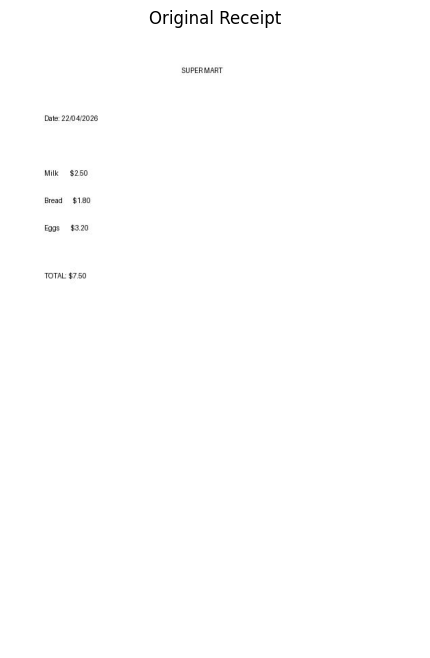

In [8]:
img = Image.open(img_path)

plt.figure(figsize=(6,8))
plt.imshow(img)
plt.title("Original Receipt")
plt.axis('off')

In [9]:
text = pytesseract.image_to_string(img)

print("=== TESSERACT OUTPUT ===")
print(text)

=== TESSERACT OUTPUT ===
SUPERMART

Date: 22/04/2026

Milk $250

Bread $180

Fags $3.20

TOTAL $750



In [10]:
data = pytesseract.image_to_data(img, output_type='dict')
df = pd.DataFrame(data)

df = df[df['text'].str.strip() != '']
df = df[df['conf'] != -1]

print(df[['text','conf']].head(10))
print("Average Confidence:", df['conf'].mean())

          text  conf
4    SUPERMART    91
8        Date:    75
9   22/04/2026    75
13        Milk    64
14        $250    70
18       Bread    56
19        $180    56
23        Fags    65
24       $3.20    65
28       TOTAL    92
Average Confidence: 71.18181818181819


In [11]:
reader = easyocr.Reader(['en'])

result = reader.readtext(img_path)

print("=== EASYOCR OUTPUT ===")
for r in result:
    print(r[1], "| Confidence:", r[2])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EASYOCR OUTPUT ===
SUPERMART | Confidence: 0.9627185994311626
Date: 22,04/2026 | Confidence: 0.38533361630887725
Milk | Confidence: 0.9999477863311768
$2.50 | Confidence: 0.9035923284637487
Bread | Confidence: 0.9979010814617492
$1.80 | Confidence: 0.6952401224526839
Eggs | Confidence: 0.9999819993972778
$3.20 | Confidence: 0.42190639060549884
TOTAL: $7.50 | Confidence: 0.8993522165973927


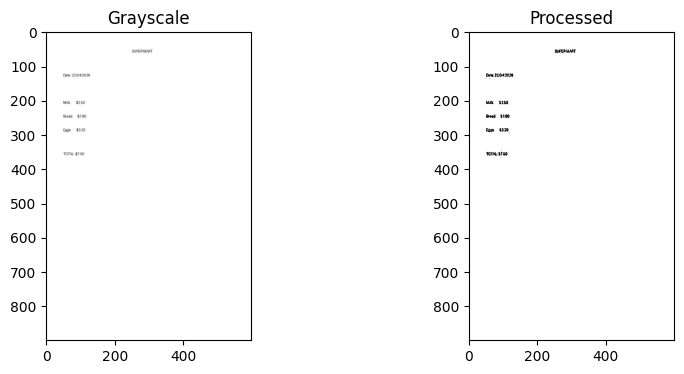

In [12]:
img_cv = cv2.imread(img_path)

gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Processed")

plt.show()

In [13]:
text_original = pytesseract.image_to_string(
    Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
)

text_processed = pytesseract.image_to_string(
    Image.fromarray(thresh)
)

print("=== ORIGINAL TEXT ===")
print(text_original)

print("\n=== PROCESSED TEXT ===")
print(text_processed)

=== ORIGINAL TEXT ===
SUPERMART

Date: 22/04/2026

Milk $250

Bread $180

Fags $3.20

TOTAL $750


=== PROCESSED TEXT ===
ae 22042008

ax $250
Goad $180

fas 9320,

TOTAL $780

SRRUART



In [14]:
def compare_ocr(image_path):
    img = cv2.imread(image_path)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.adaptiveThreshold(
        blur,255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,11,2
    )
    
    tess = pytesseract.image_to_string(Image.fromarray(thresh))
    
    easy = reader.readtext(image_path)
    easy_text = " ".join([r[1] for r in easy])
    
    return tess, easy_text

t, e = compare_ocr(img_path)

print("Tesseract:", t)
print("EasyOCR:", e)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tesseract: ae 22042008

ax $250
Goad $180

fas 9320,

TOTAL $780

SRRUART

EasyOCR: SUPERMART Date: 22,04/2026 Milk $2.50 Bread $1.80 Eggs $3.20 TOTAL: $7.50


In [15]:
match = re.search(r'\$\d+(\.\d+)?', text_processed)

if match:
    print("Detected Total:", match.group())

Detected Total: $250
